# Post-hoc C/IER Indicators

Pablo Rogers

In [ ]:

# Load necessary packages for analysis and plotting
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

In [ ]:

# Read eligible data from Level 1
imported_data <- read_csv2(
    "../../Data/IntermediateData/whoqol_imported.csv",
    show_col_types = FALSE
)


ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

## Helper functions definition

In [ ]:

# Laz.R index (Biemann et al., 2025)
calc_lazr <- function(x) {
    tr <- table(x[-length(x)], x[-1], useNA = "ifany")
    sum(tr^2 / rowSums(tr)) / (length(x) - 1)
}

# Kneedle Algorithm (Biemann et al., 2025)
dist2d <- function(a, b, c) {
    v1 <- b - c
    v2 <- a - b
    m <- cbind(v1, v2)
    det(m) / sqrt(sum(v1 * v1))
}

kneedle <- function(values, sign) {
    start <- c(1, values[1])
    end <- c(length(values), values[length(values)])
    which.max(lapply(seq_along(values), function(idx) {
        sign * -1 * dist2d(c(idx, values[idx]), start, end)
    }))
}


## Calculation of the four indicators

The IRV and longstring are calculated using the `careless` package. The Laz.R is calculated through the `calc_lazr` function, and MD is calculated via the `modi` package using the `MDmiss` function to handle missing values.

In [ ]:

# Calculate Laz.R
lazr_vals <- apply(items, 1, calc_lazr)

# Calculate Longstring index
longstr_vals <- longstring(items)

# Calculate Mahalanobis Distance adjusting for missing values
md_vals <- as.numeric(MDmiss(
    data = as.matrix(items),
    center = colMeans(items, na.rm = TRUE),
    cov = cov(items, use = "pairwise.complete.obs")
))

# Calculate Intra-Individual Response Variability (IRV)
irv_vals <- irv(items, split = FALSE)


## Individual variables

In [ ]:

# Consolidate all calculated indicators into a single dataset
df_indicators <- tibble(
    ID      = id_col,
    LazR    = round(lazr_vals, 3),
    Longstr = as.integer(longstr_vals),
    MD      = round(md_vals, 3),
    IRV     = round(irv_vals, 3)
)

df_indicators


# A tibble: 1,295 × 5
            ID  LazR Longstr    MD   IRV
         <dbl> <dbl>   <int> <dbl> <dbl>
 1 10441016017 0.413       4 49.5  1.25 
 2 10440981694 0.502       5 13.5  0.634
 3 10440601239 0.5         6 79.0  1.47 
 4 10440562981 0.567       9 27.3  0.999
 5 10440358563 0.46        8 32.2  1.22 
 6 10440199369 0.673      11  6.94 0.528
 7 10438952564 0.416       5 39.9  0.977
 8 10438951127 0.395       3 24.1  0.796
 9 10438633244 0.447       4 41.8  0.857
10 10438605204 0.479       5 12.2  0.637
# ℹ 1,285 more rows

## Univariate visualization

### Laz.R

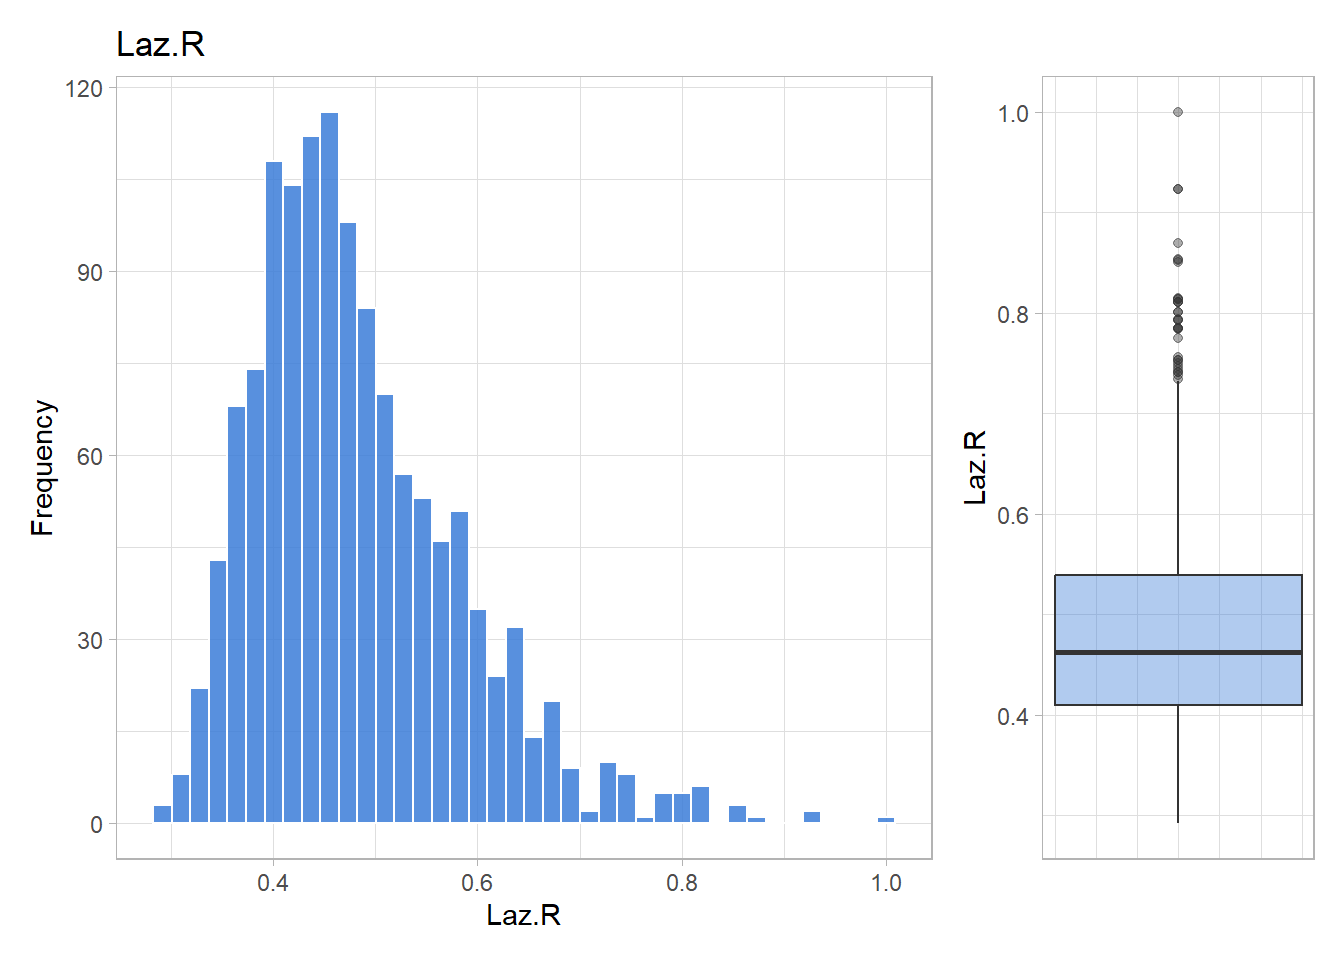

In [ ]:

# Plot histogram and boxplot for Laz.R distribution
p_hist_lazr <- ggplot(df_indicators, aes(x = LazR)) +
    geom_histogram(bins = 40, fill = "#3B7DD8", color = "white", alpha = 0.85) +
    labs(title = "Laz.R", x = "Laz.R", y = "Frequency") +
    theme_light()

p_box_lazr <- ggplot(df_indicators, aes(y = LazR)) +
    geom_boxplot(fill = "#3B7DD8", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "Laz.R") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

# Save plot
p_combined_lazr <- p_hist_lazr + p_box_lazr + plot_layout(widths = c(3, 1))
ggsave("../../Output/DataAppendixOutput/Figures/viz-lazr.png", p_combined_lazr, width = 8, height = 4)
p_combined_lazr


### Longstring

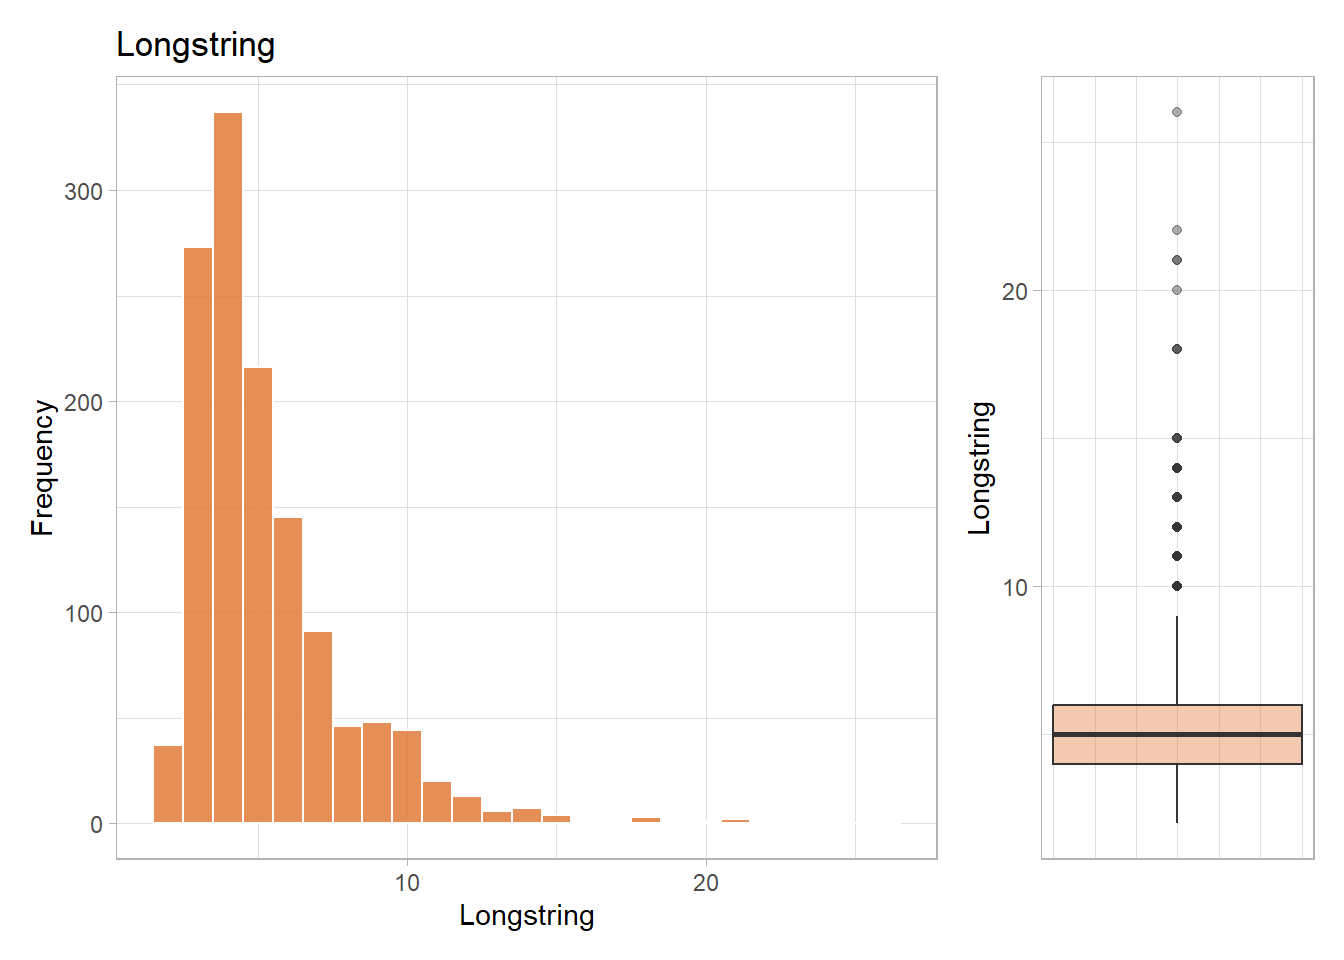

In [ ]:

# Plot histogram and boxplot for Longstring distribution
p_hist_ls <- ggplot(df_indicators, aes(x = Longstr)) +
    geom_histogram(binwidth = 1, fill = "#E07B39", color = "white", alpha = 0.85) +
    labs(title = "Longstring", x = "Longstring", y = "Frequency") +
    theme_light()

p_box_ls <- ggplot(df_indicators, aes(y = Longstr)) +
    geom_boxplot(fill = "#E07B39", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "Longstring") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

# Save plot
p_combined_ls <- p_hist_ls + p_box_ls + plot_layout(widths = c(3, 1))
ggsave("../../Output/DataAppendixOutput/Figures/viz-longstr.png", p_combined_ls, width = 8, height = 4)
p_combined_ls


### Mahalanobis Distance

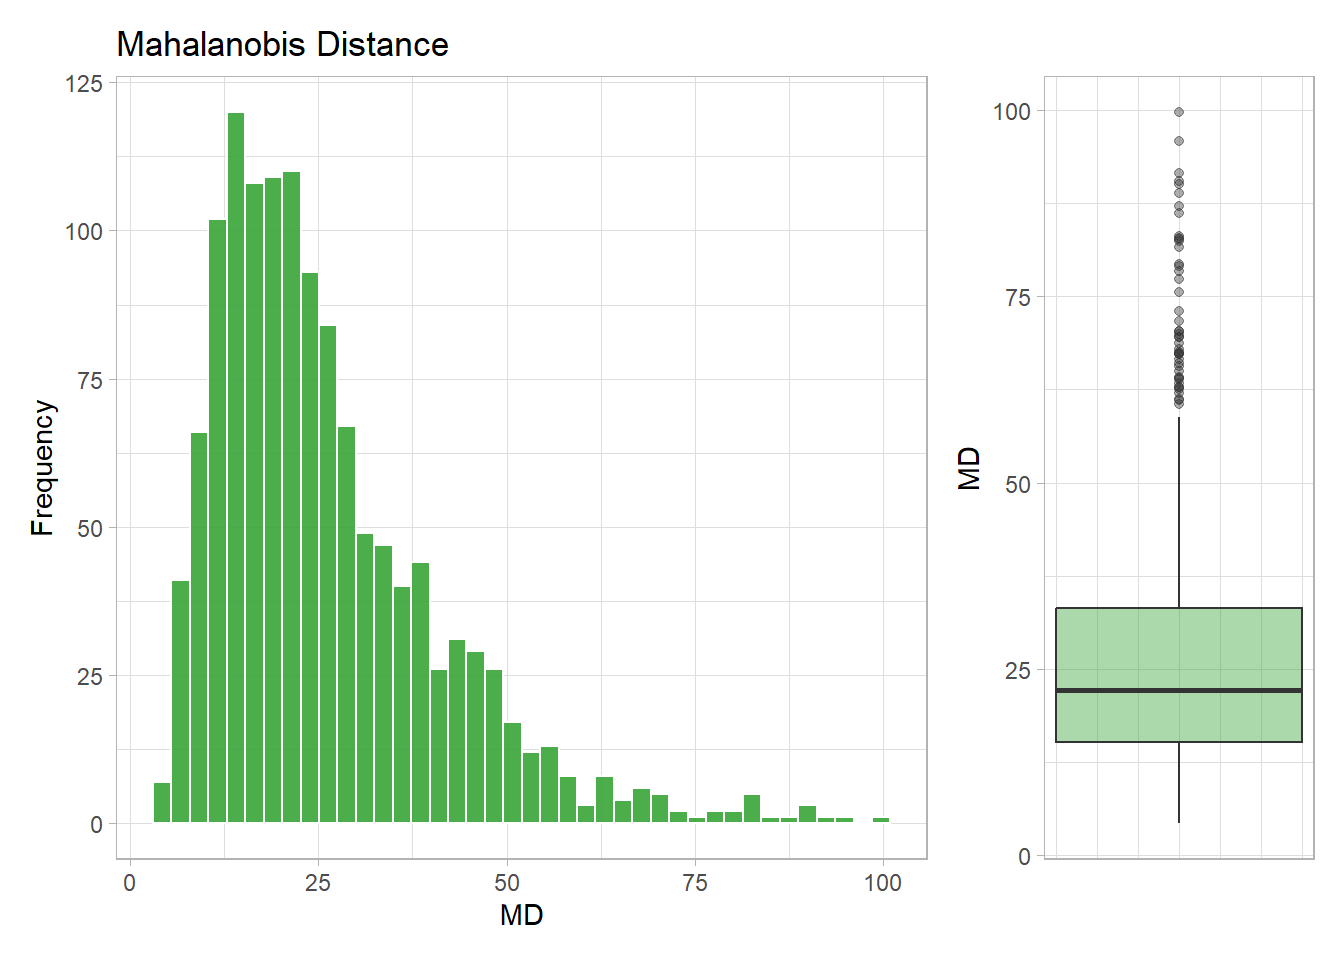

In [ ]:

# Plot histogram and boxplot for Mahalanobis Distance distribution
p_hist_md <- ggplot(df_indicators, aes(x = MD)) +
    geom_histogram(bins = 40, fill = "#2CA02C", color = "white", alpha = 0.85) +
    labs(title = "Mahalanobis Distance", x = "MD", y = "Frequency") +
    theme_light()

p_box_md <- ggplot(df_indicators, aes(y = MD)) +
    geom_boxplot(fill = "#2CA02C", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "MD") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

# Save plot
p_combined_md <- p_hist_md + p_box_md + plot_layout(widths = c(3, 1))
ggsave("../../Output/DataAppendixOutput/Figures/viz-md.png", p_combined_md, width = 8, height = 4)
p_combined_md


### IRV

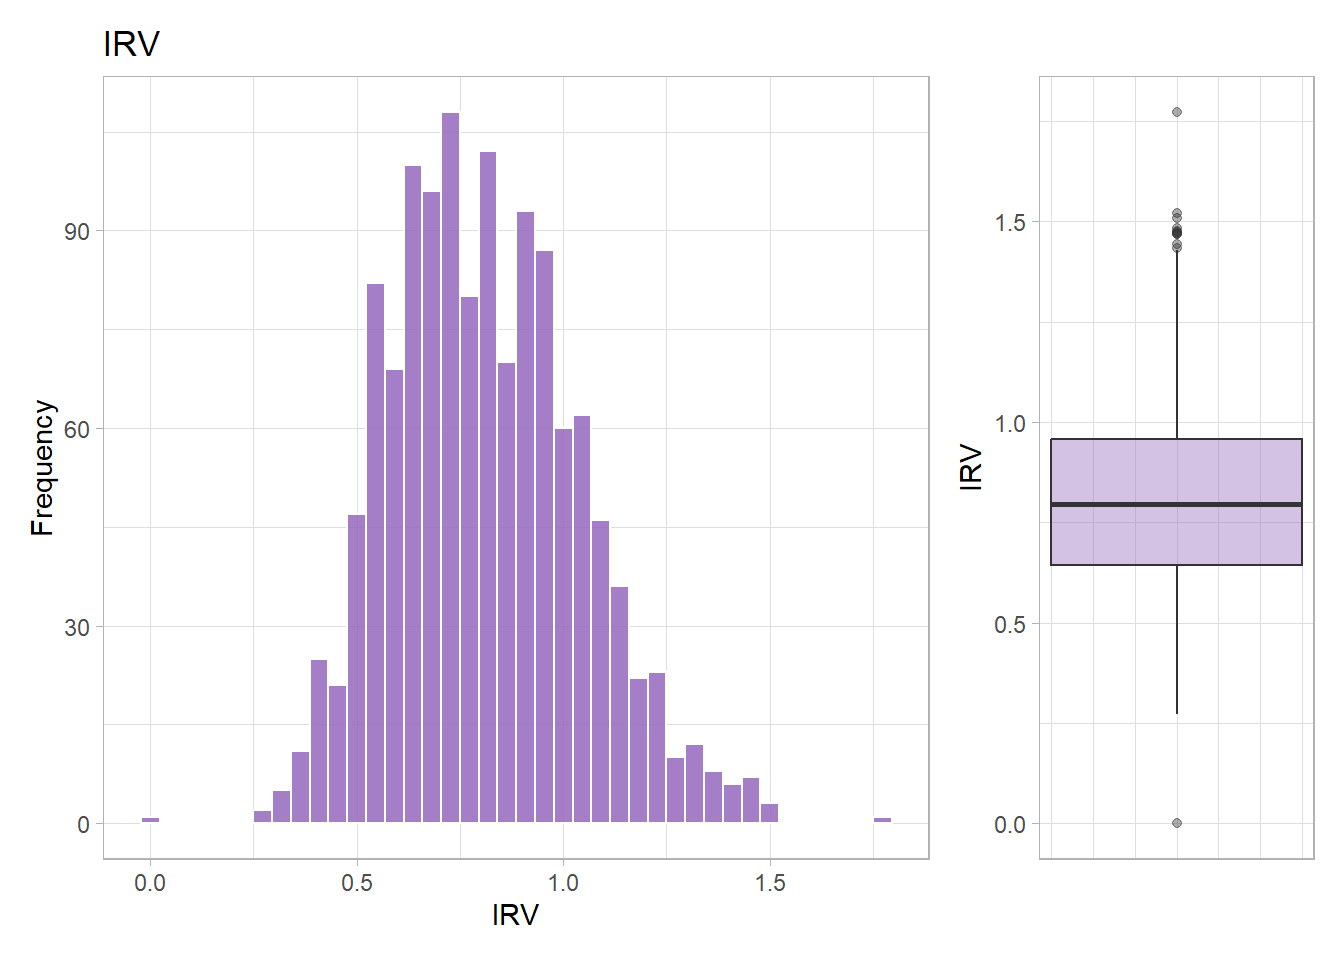

In [ ]:

# Plot histogram and boxplot for IRV distribution
p_hist_irv <- ggplot(df_indicators, aes(x = IRV)) +
    geom_histogram(bins = 40, fill = "#9467BD", color = "white", alpha = 0.85) +
    labs(title = "IRV", x = "IRV", y = "Frequency") +
    theme_light()

p_box_irv <- ggplot(df_indicators, aes(y = IRV)) +
    geom_boxplot(fill = "#9467BD", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "IRV") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

# Save plot
p_combined_irv <- p_hist_irv + p_box_irv + plot_layout(widths = c(3, 1))
ggsave("../../Output/DataAppendixOutput/Figures/viz-irv.png", p_combined_irv, width = 8, height = 4)
p_combined_irv


## Cut-off points via Kneedle algorithm

In [ ]:

# Define function to calculate Kneedle point based on sorted values
calc_kneedle <- function(x, sign_val) {
    x_sorted <- sort(x, decreasing = TRUE, na.last = NA)
    n <- length(x_sorted)
    if (n == 0 || sum(x_sorted, na.rm = TRUE) == 0) {
        return(list(pct = NA_real_, crit = NA_real_, sorted = x_sorted))
    }
    pos <- kneedle(x_sorted, sign_val)
    pct <- pos / n
    crit <- quantile(x_sorted, probs = 1 - pct, na.rm = TRUE, names = FALSE)
    list(pct = pct, crit = crit, sorted = x_sorted)
}

# Calculate cut-off points for each indicator
kn_lazr <- calc_kneedle(df_indicators$LazR, -1)
kn_longstr <- calc_kneedle(df_indicators$Longstr, -1)
kn_md <- calc_kneedle(df_indicators$MD, -1)
kn_irv_high <- calc_kneedle(df_indicators$IRV, -1)
kn_irv_low <- calc_kneedle(df_indicators$IRV, +1)

# Tabulate the critical cut-off values and percentage of flagged responses
cutoff_tab <- tibble(
    Indicator = c(
        "Laz.R", "Longstring", "MD",
        "IRV (high end)", "IRV (low end)"
    ),
    `Critical value` = round(c(
        kn_lazr$crit, kn_longstr$crit, kn_md$crit,
        kn_irv_high$crit, kn_irv_low$crit
    ), 2),
    `% flagged` = round(c(
        kn_lazr$pct, kn_longstr$pct, kn_md$pct,
        kn_irv_high$pct, 1 - kn_irv_low$pct
    ) * 100, 1)
)

# Save table
write_csv2(cutoff_tab, "../../Output/DataAppendixOutput/Tables/kneedle-cutoffs.csv")

# Print table
cutoff_tab |>
    knitr::kable(
        caption = "Cut-off points — Kneedle algorithm (Biemann et al., 2025)",
        digits  = c(0, 2, 1)
    )


  Indicator          Critical value   \% flagged
  ---------------- ---------------- ------------
  Laz.R                        0.60         11.6
  Longstring                   7.00         15.2
  MD                          40.12         15.4
  IRV (high end)               1.14          8.0
  IRV (low end)                0.48          5.0

  : Cut-off points --- Kneedle algorithm (Biemann et al., 2025)


## Plots with cut-off points

### Laz.R

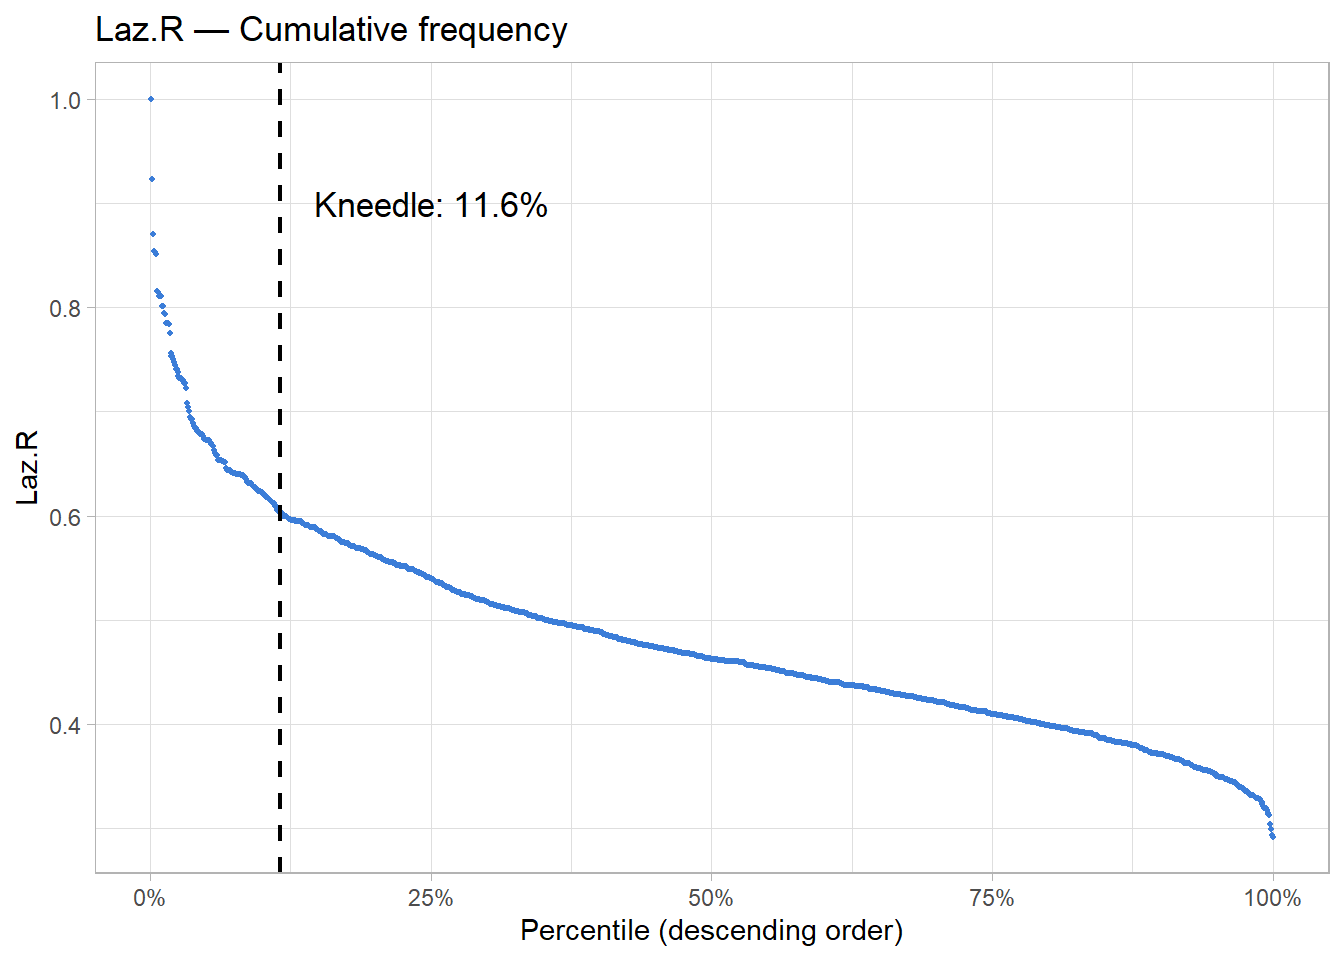

In [ ]:

# Builds the data frame for the cumulative curve (descending order)
make_cum_df <- function(sorted_vals) {
    n <- length(sorted_vals)
    tibble(Index_value = sorted_vals, percent = seq_len(n) / n)
}

# Create cumulative frequency plot for Laz.R with cut-off line
cum_lazr <- make_cum_df(kn_lazr$sorted)

p_cum_lazr <- ggplot(cum_lazr, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#3B7DD8") +
    geom_vline(xintercept = kn_lazr$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_lazr$pct + 0.03, y = max(cum_lazr$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_lazr$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Laz.R — Cumulative frequency",
        x = "Percentile (descending order)", y = "Laz.R"
    ) +
    theme_light()

# Save plot
ggsave("../../Output/DataAppendixOutput/Figures/cum-lazr.png", p_cum_lazr, width = 6, height = 4)
p_cum_lazr


### Longstring

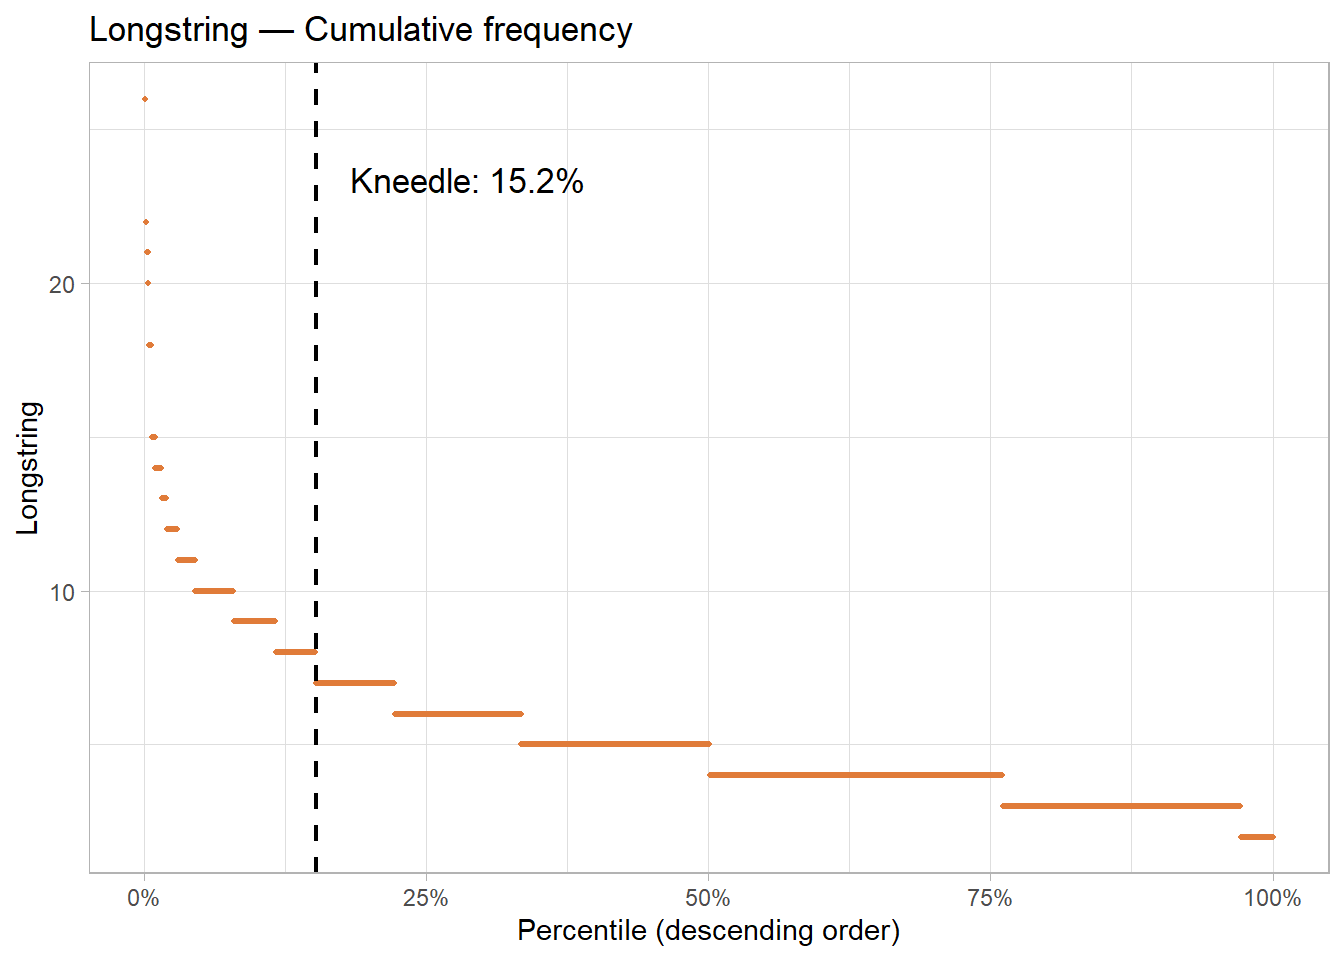

In [ ]:

# Create cumulative frequency plot for Longstring with cut-off line
cum_ls <- make_cum_df(kn_longstr$sorted)

p_cum_ls <- ggplot(cum_ls, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#E07B39") +
    geom_vline(xintercept = kn_longstr$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_longstr$pct + 0.03, y = max(cum_ls$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_longstr$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Longstring — Cumulative frequency",
        x = "Percentile (descending order)", y = "Longstring"
    ) +
    theme_light()

# Save plot
ggsave("../../Output/DataAppendixOutput/Figures/cum-longstr.png", p_cum_ls, width = 6, height = 4)
p_cum_ls


### Mahalanobis Distance

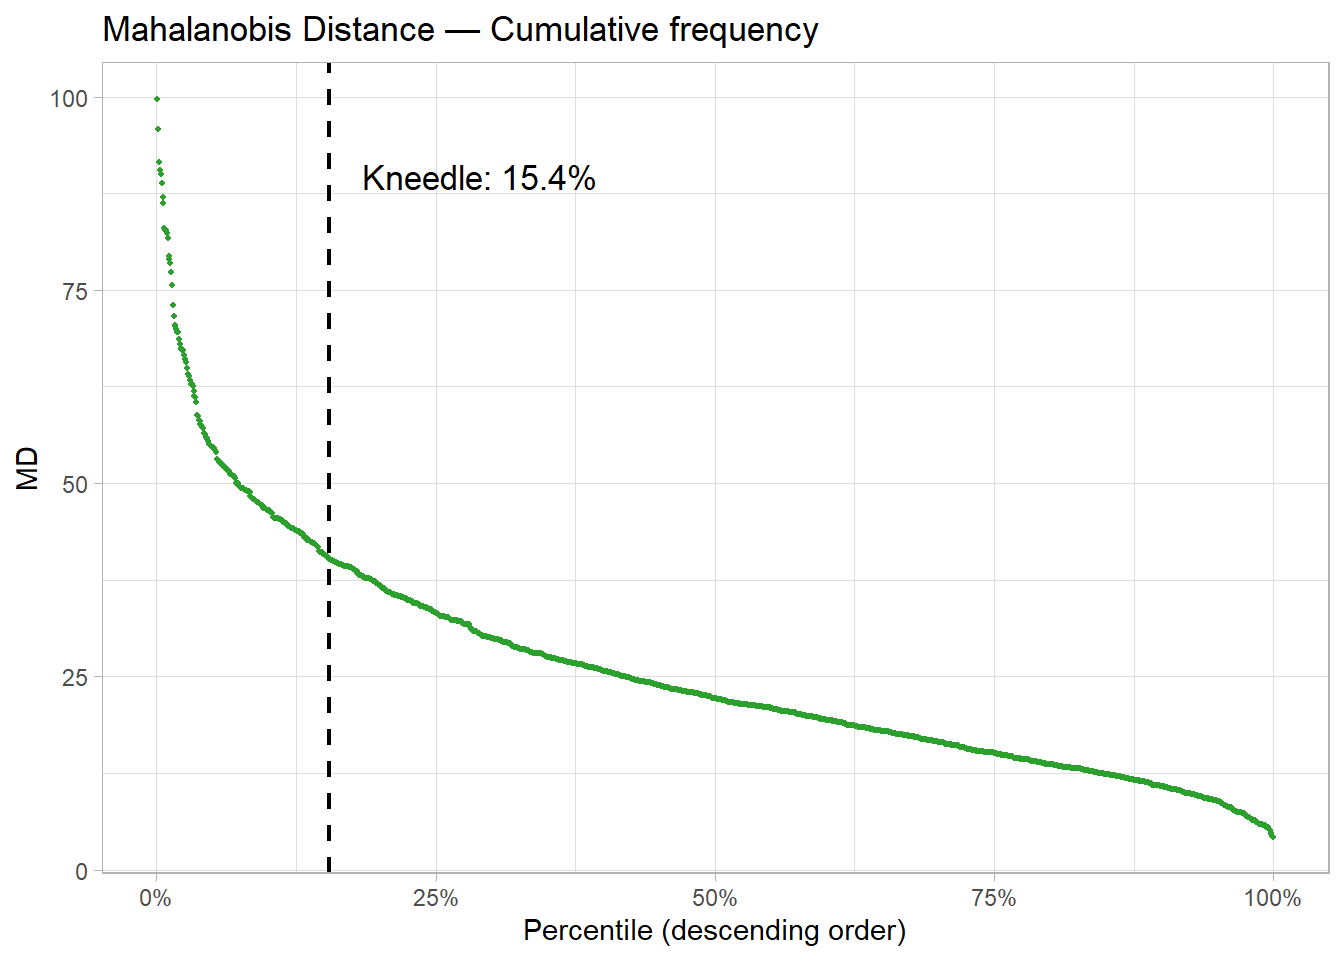

In [ ]:

# Create cumulative frequency plot for Mahalanobis Distance with cut-off line
cum_md <- make_cum_df(kn_md$sorted)

p_cum_md <- ggplot(cum_md, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#2CA02C") +
    geom_vline(xintercept = kn_md$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_md$pct + 0.03, y = max(cum_md$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_md$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Mahalanobis Distance — Cumulative frequency",
        x = "Percentile (descending order)", y = "MD"
    ) +
    theme_light()

# Save plot
ggsave("../../Output/DataAppendixOutput/Figures/cum-md.png", p_cum_md, width = 6, height = 4)
p_cum_md


### IRV

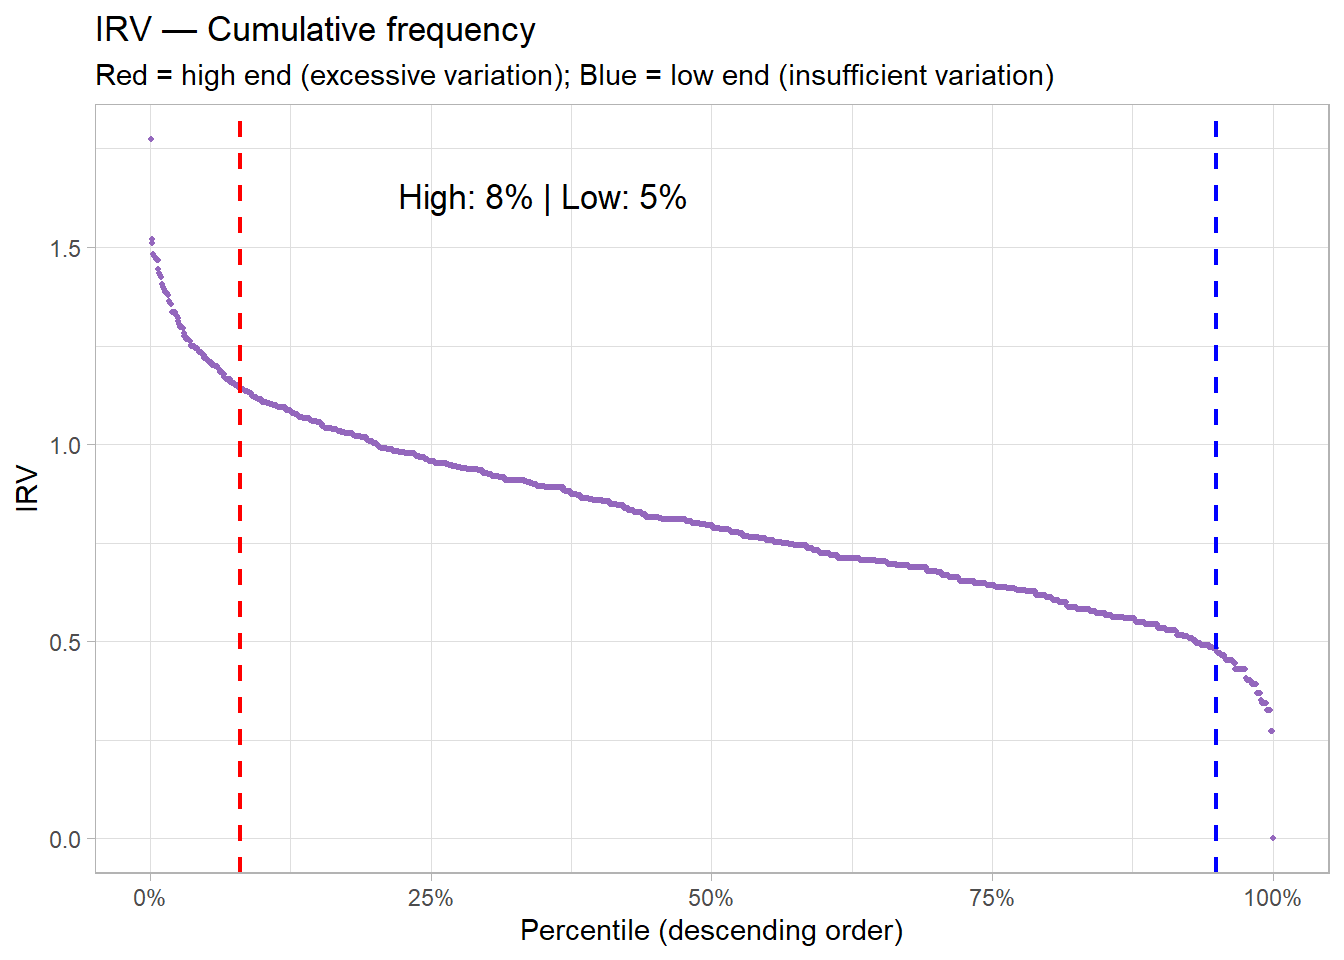

In [ ]:

# Create cumulative frequency plot for IRV with high and low cut-off lines
cum_irv <- make_cum_df(kn_irv_high$sorted)

p_cum_irv <- ggplot(cum_irv, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#9467BD") +
    geom_vline(
        xintercept = kn_irv_high$pct, linetype = "dashed", linewidth = 0.8,
        color = "red"
    ) +
    geom_vline(
        xintercept = kn_irv_low$pct, linetype = "dashed", linewidth = 0.8,
        color = "blue"
    ) +
    annotate("text",
        x = 0.35, y = max(cum_irv$Index_value, na.rm = TRUE) * 0.92,
        label = paste0(
            "High: ", round(kn_irv_high$pct * 100, 1),
            "% | Low: ", round((1 - kn_irv_low$pct) * 100, 1), "%"
        ),
        size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "IRV — Cumulative frequency",
        subtitle = "Red = high end (excessive variation); Blue = low end (insufficient variation)",
        x = "Percentile (descending order)", y = "IRV"
    ) +
    theme_light()

# Save plot
ggsave("../../Output/DataAppendixOutput/Figures/cum-irv.png", p_cum_irv, width = 6, height = 4)
p_cum_irv


## C/IER Flags

In [ ]:

# Generate binary identifiers for respondents exceeding indicator thresholds
df_flags <- df_indicators |>
    mutate(
        LazR_FLAG     = if_else(LazR >= kn_lazr$crit, 1L, 0L),
        Longstr_FLAG  = if_else(Longstr > kn_longstr$crit, 1L, 0L),
        MD_FLAG       = if_else(MD >= kn_md$crit, 1L, 0L),
        IRV_high_FLAG = if_else(IRV >= kn_irv_high$crit, 1L, 0L),
        IRV_low_FLAG  = if_else(IRV <= kn_irv_low$crit, 1L, 0L)
    )

df_flags


# A tibble: 1,295 × 10
            ID  LazR Longstr    MD   IRV LazR_FLAG Longstr_FLAG MD_FLAG
         <dbl> <dbl>   <int> <dbl> <dbl>     <int>        <int>   <int>
 1 10441016017 0.413       4 49.5  1.25          0            0       1
 2 10440981694 0.502       5 13.5  0.634         0            0       0
 3 10440601239 0.5         6 79.0  1.47          0            0       1
 4 10440562981 0.567       9 27.3  0.999         0            1       0
 5 10440358563 0.46        8 32.2  1.22          0            1       0
 6 10440199369 0.673      11  6.94 0.528         1            1       0
 7 10438952564 0.416       5 39.9  0.977         0            0       0
 8 10438951127 0.395       3 24.1  0.796         0            0       0
 9 10438633244 0.447       4 41.8  0.857         0            0       1
10 10438605204 0.479       5 12.2  0.637         0            0       0
# ℹ 1,285 more rows
# ℹ 2 more variables: IRV_high_FLAG <int>, IRV_low_FLAG <int>

### Flags overview

In [ ]:

# Summarize the count and percentage of flagged respondents globally
table_flags <- df_flags |>
    summarise(
        across(ends_with("_FLAG"), list(
            n_flagged   = \(x) sum(x, na.rm = TRUE),
            pct_flagged = \(x) round(mean(x, na.rm = TRUE) * 100, 1)
        ))
    ) |>
    pivot_longer(everything(),
        names_to = c("Indicator", ".value"),
        names_pattern = "(.+)_(n_flagged|pct_flagged)"
    )

# Save table
write_csv2(table_flags, "../../Output/DataAppendixOutput/Tables/flags-overview.csv")

# Print table
table_flags |>
    knitr::kable(
        caption = "Summary of flagged C/IER respondents",
        col.names = c("Indicator", "N flagged", "% flagged")
    )


  Indicator         N flagged   \% flagged
  --------------- ----------- ------------
  LazR_FLAG               152         11.7
  Longstr_FLAG            196         15.1
  MD_FLAG                 201         15.5
  IRV_high_FLAG           108          8.3
  IRV_low_FLAG             65          5.0

  : Summary of flagged C/IER respondents


In [ ]:

# Merge indicators with original data and export for final evaluation
screened_data <- imported_data |>
    select(ID, Q1:Q26) |>
    left_join(df_flags, by = "ID")

write_csv2(screened_data, "../../Data/IntermediateData/whoqol_screened.csv")

# Extract only ID and items for the Confirmatory Factor Analysis (CFA)
final_analysis_data <- screened_data |>
  select(ID, Q1:Q26)

# Export final analytical dataset
write_csv2(final_analysis_data, "../../Data/AnalysisData/whoqol_analysis.csv")
